In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from smrt.permittivity.saline_ice import saline_ice_permittivity_pvs_mixing as pvs
from smrt.permittivity.saline_snow import saline_snow_permittivity_geldsetzer09 as geldsetzer
import numpy as np

In [16]:
def get_BVF(S_bulk,T_degC):

    BVF = S_bulk*(-49.185/T_degC + 0.532)

    return BVF

def get_fresnel(temp_K,snow_sal_kgkg,snow_den_kgm3,ice_sal_kgkg,freq_ku=13.5e9):
    
    ice_bvf= get_BVF(ice_sal_kgkg,temp_K-273.15)
    n_ice = np.sqrt(abs(pvs(freq_ku,temp_K,ice_bvf)))
    n_snow = np.sqrt(abs(geldsetzer(freq_ku,snow_den_kgm3,temp_K,snow_sal_kgkg)))

    fresnel =  abs(  (n_snow-n_ice)/(n_snow+n_ice) ) **2 

    return fresnel

# BEFORE

In [21]:
snow_ice_interface_temps = 273.15+np.asarray([-4.8,-4.9,-4.8,-4.9,-4.7,-4.6,-4.7])
scraping_sal= 0.001*np.asarray([16.39,18.53,22.05,17.45,19.06,23.98,22.23])
basal_sal=0.001*np.asarray([17.98,19.47,21.11,20.68,22.64,20.69,22.18])
basal_dens=1000*np.asarray([0.176,0.176,0.184,0.188,0.184,0.184,0.192])

0.03876224234217056 0.0008372774616764193


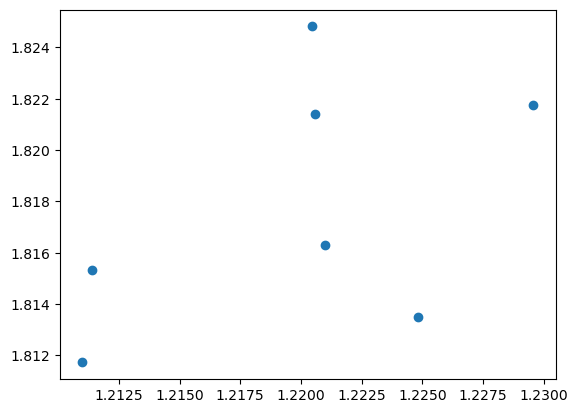

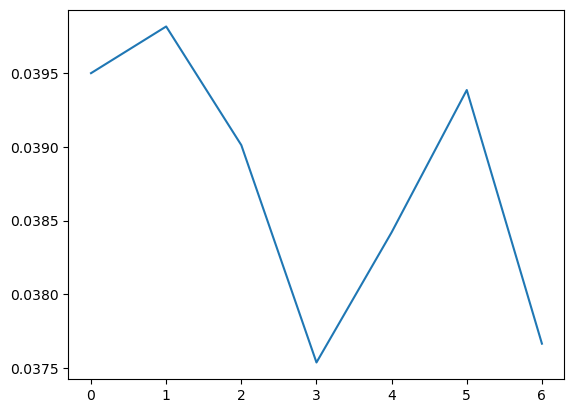

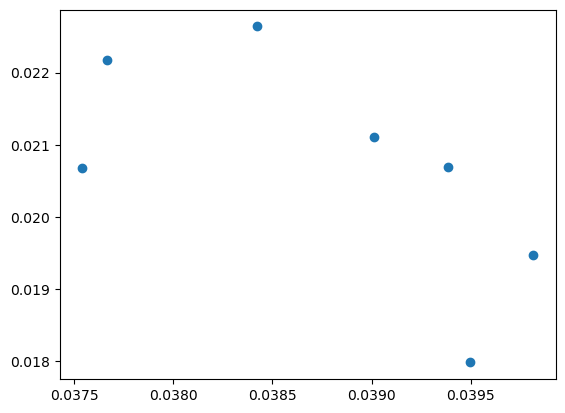

In [32]:
freq_ku = 13.5e9

n_ice=[]
n_snow=[]
for ice_sal_kgkg,snow_sal_kgkg,temp_K,snow_den_kgm3 in zip(scraping_sal,basal_sal,snow_ice_interface_temps,basal_dens):
        
    ice_bvf= get_BVF(ice_sal_kgkg,temp-273.15)
    n_ice.append( np.sqrt(abs(pvs(freq_ku,temp_K,ice_bvf))))
    n_snow.append( np.sqrt(abs(geldsetzer(freq_ku,snow_den_kgm3,temp,snow_sal_kgkg))))



df = pd.DataFrame({'n_snow':n_snow,'n_ice':n_ice})
df['ratio']=df['n_snow']/df['n_ice']
df['fresnel'] = np.abs(  (df['n_snow']-df['n_ice'])/(df['n_snow']+df['n_ice']) ) **2 

print(np.nanmean(df['fresnel']),np.nanstd(df['fresnel']))

plt.scatter(df['n_snow'],df['n_ice'])
plt.show()
plt.plot(df['fresnel'])
plt.show()
plt.scatter(df['fresnel'],basal_sal)